### RDP on Individual Participant Files

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pickle 
import os
import pandas as pd
from collections import defaultdict

os.chdir(r"C:\Users\Alishba\Downloads\prediction files\Transcriptions\Trajectory Analysis\complete embeddings")
with open("subid_mapping.p", "rb") as f:
    subid_mapping = pickle.load(f)

# Create a dictionary to store each participant's session data
participants = {}

# Iterate through the DataFrame
for participant_id in subid_mapping.index:
    session1_debug = subid_mapping.loc[participant_id, 'session 1']
    session2_debug = subid_mapping.loc[participant_id, 'session 2']
    
    participants[participant_id] = {
        'session_1': session1_debug,
        'session_2': session2_debug
    }
    
# Print all participants
# print("\nAll participants:")
# for pid, data in participants.items():
#     print(f"{pid}: Session 1 = {data['session_1']}, Session 2 = {data['session_2']}")

with open("imm-del-embs.p", "rb") as f:
    imm_del_embs = pickle.load(f)

# Create matched pairs using the debug IDs from subid_mapping
matched_participants = {}

for participant_id, session_data in participants.items():
    session1_debug = session_data['session_1']
    session2_debug = session_data['session_2']
    
    # Initialize data holders
    immediate_embeddings = None
    delayed_embeddings = None
    
    # Search for session 1 (immediate) in participants_immediate
    for debug_id, embeddings in imm_del_embs['participants_immediate']:
        if debug_id == session1_debug:
            immediate_embeddings = np.array(embeddings)
            break
    
    # Search for session 2 (delayed) in participants_delayed
    for debug_id, embeddings in imm_del_embs['participants_delayed']:
        if debug_id == session2_debug:
            delayed_embeddings = np.array(embeddings)
            break
    
    # Only add if both sessions were found
    if immediate_embeddings is not None and delayed_embeddings is not None:
        matched_participants[participant_id] = {
            'session1_debug': session1_debug,
            'session2_debug': session2_debug,
            'immediate': immediate_embeddings,
            'delayed': delayed_embeddings
        }

# Print results
# print(f"\nSuccessfully matched {len(matched_participants)} participants")
# print("\nSample matched participants:")
# for i, (pid, data) in enumerate(list(matched_participants.items())[:3]):
#     print(f"{i+1}. {pid}")
#     print(f"   Session 1: {data['session1_debug']}")
#     print(f"   Session 2: {data['session2_debug']}")
#     print(f"   Immediate shape: {data['immediate'].shape}")
#     print(f"   Delayed shape: {data['delayed'].shape}")
#     print()

def run_rdp_individual(events, epsilon_factor=0.1):
    """Run RDP on individual participant data"""
    
    def calculate_perpendicular_distance(point, line_start, line_end):
        x0, y0 = point
        x1, y1 = line_start
        x2, y2 = line_end
        
        if x1 == x2 and y1 == y2:
            return np.sqrt((x0-x1)**2 + (y0-y1)**2)
        
        distance = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1) / np.sqrt((y2-y1)**2 + (x2-x1)**2)
        return distance

    def find_farthest_point(points, start_idx, end_idx):
        if end_idx - start_idx <= 1:
            return -1, 0
        
        line_start = points[start_idx]
        line_end = points[end_idx]
        
        max_distance = 0
        farthest_idx = -1
        
        for i in range(start_idx + 1, end_idx):
            distance = calculate_perpendicular_distance(points[i], line_start, line_end)
            if distance > max_distance:
                max_distance = distance
                farthest_idx = i
        
        return farthest_idx, max_distance

    def rdp_recursive(points, start_idx, end_idx, epsilon, kept_indices):
        farthest_idx, max_distance = find_farthest_point(points, start_idx, end_idx)
        
        if farthest_idx != -1 and max_distance > epsilon:
            kept_indices.append(farthest_idx)
            rdp_recursive(points, start_idx, farthest_idx, epsilon, kept_indices)
            rdp_recursive(points, farthest_idx, end_idx, epsilon, kept_indices)
    
    # Find initial max distance for epsilon calculation
    x1, y1 = events[0]
    x2, y2 = events[-1]
    
    max_distance = 0
    for (x0, y0) in events:
        d = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1) / np.sqrt((y2-y1)**2 + (x2-x1)**2)
        if d > max_distance:
            max_distance = d
    
    epsilon = epsilon_factor * max_distance
    kept_indices = [0, len(events)-1]
    
    rdp_recursive(events, 0, len(events)-1, epsilon, kept_indices)
    kept_indices.sort()
    
    return kept_indices, epsilon, len(events)

# Run RDP on all matched participants
analyzed_participants = {}

print("Running RDP analysis on all matched participants...")
for participant_id, data in matched_participants.items():
    immediate_events = data['immediate']
    delayed_events = data['delayed']
    
    # Run RDP on immediate
    imm_kept, imm_epsilon, imm_total = run_rdp_individual(immediate_events)
    
    # Run RDP on delayed
    del_kept, del_epsilon, del_total = run_rdp_individual(delayed_events)
    
    # Store results
    analyzed_participants[participant_id] = {
        'immediate': {
            'events': immediate_events,
            'kept_indices': imm_kept,
            'epsilon': imm_epsilon,
            'total_points': imm_total,
            'num_kept': len(imm_kept),
            'compression_ratio': len(imm_kept) / imm_total
        },
        'delayed': {
            'events': delayed_events,
            'kept_indices': del_kept,
            'epsilon': del_epsilon,
            'total_points': del_total,
            'num_kept': len(del_kept),
            'compression_ratio': len(del_kept) / del_total
        }
    }

print(f"Completed RDP analysis for {len(analyzed_participants)} participants\n")

# Create a summary DataFrame
summary_data = []

for participant_id, results in analyzed_participants.items():
    summary_data.append({
        'Participant_ID': participant_id,
        'Immediate_Total_Points': results['immediate']['total_points'],
        'Immediate_Kept_Points': results['immediate']['num_kept'],
        'Immediate_Compression_Ratio': results['immediate']['compression_ratio'],
        'Immediate_Epsilon': results['immediate']['epsilon'],
        'Immediate_Kept_Indices': str(results['immediate']['kept_indices']),
        'Delayed_Total_Points': results['delayed']['total_points'],
        'Delayed_Kept_Points': results['delayed']['num_kept'],
        'Delayed_Compression_Ratio': results['delayed']['compression_ratio'],
        'Delayed_Epsilon': results['delayed']['epsilon'],
        'Delayed_Kept_Indices': str(results['delayed']['kept_indices']),
        'Difference_Kept_Points': results['delayed']['num_kept'] - results['immediate']['num_kept'],
        'Difference_Compression': results['delayed']['compression_ratio'] - results['immediate']['compression_ratio']
    })

df_summary = pd.DataFrame(summary_data)

# Save to CSV
df_summary.to_csv('rdp_analysis_summary.csv', index=False)
print("Summary saved to 'rdp_analysis_summary.csv'")

Running RDP analysis on all matched participants...
Completed RDP analysis for 57 participants

Summary saved to 'rdp_analysis_summary.csv'


### Visualization/Figures Discussed


1. DESCRIPTIVE STATISTICS

            Metric Immediate Mean (SD) Delayed Mean (SD) Difference
Compression Ratio       0.671 (0.198)     0.732 (0.185)      0.061
          Epsilon       0.518 (0.149)     0.501 (0.146)     -0.017
      Kept Points      10.351 (3.903)     8.982 (3.558)     -1.368
     Total Points      17.702 (9.458)    13.825 (7.672)     -3.877

2. STATISTICAL ANALYSIS

            Metric Mean Diff Cohen's d           95% CI t-test p Wilcoxon p Normal?
Compression Ratio    0.0610     0.230  [-0.008, 0.130]   0.0881     0.0983     Yes
          Epsilon   -0.0170    -0.089  [-0.067, 0.033]   0.5035     0.6139     Yes
      Kept Points   -1.3684    -0.367 [-2.336, -0.401]   0.0075     0.0117     Yes
     Total Points   -3.8772    -0.383 [-6.503, -1.251]   0.0054     0.0075     Yes

✓ Saved: figure1_paired_comparison.png
✓ Saved: figure2_scatterplot_analysis.png
✓ Saved: figure3_change_distributions.png
✓ Saved: figure4_complexity_metric.png

4. SUMMARY TABLE FOR PRESENTAT

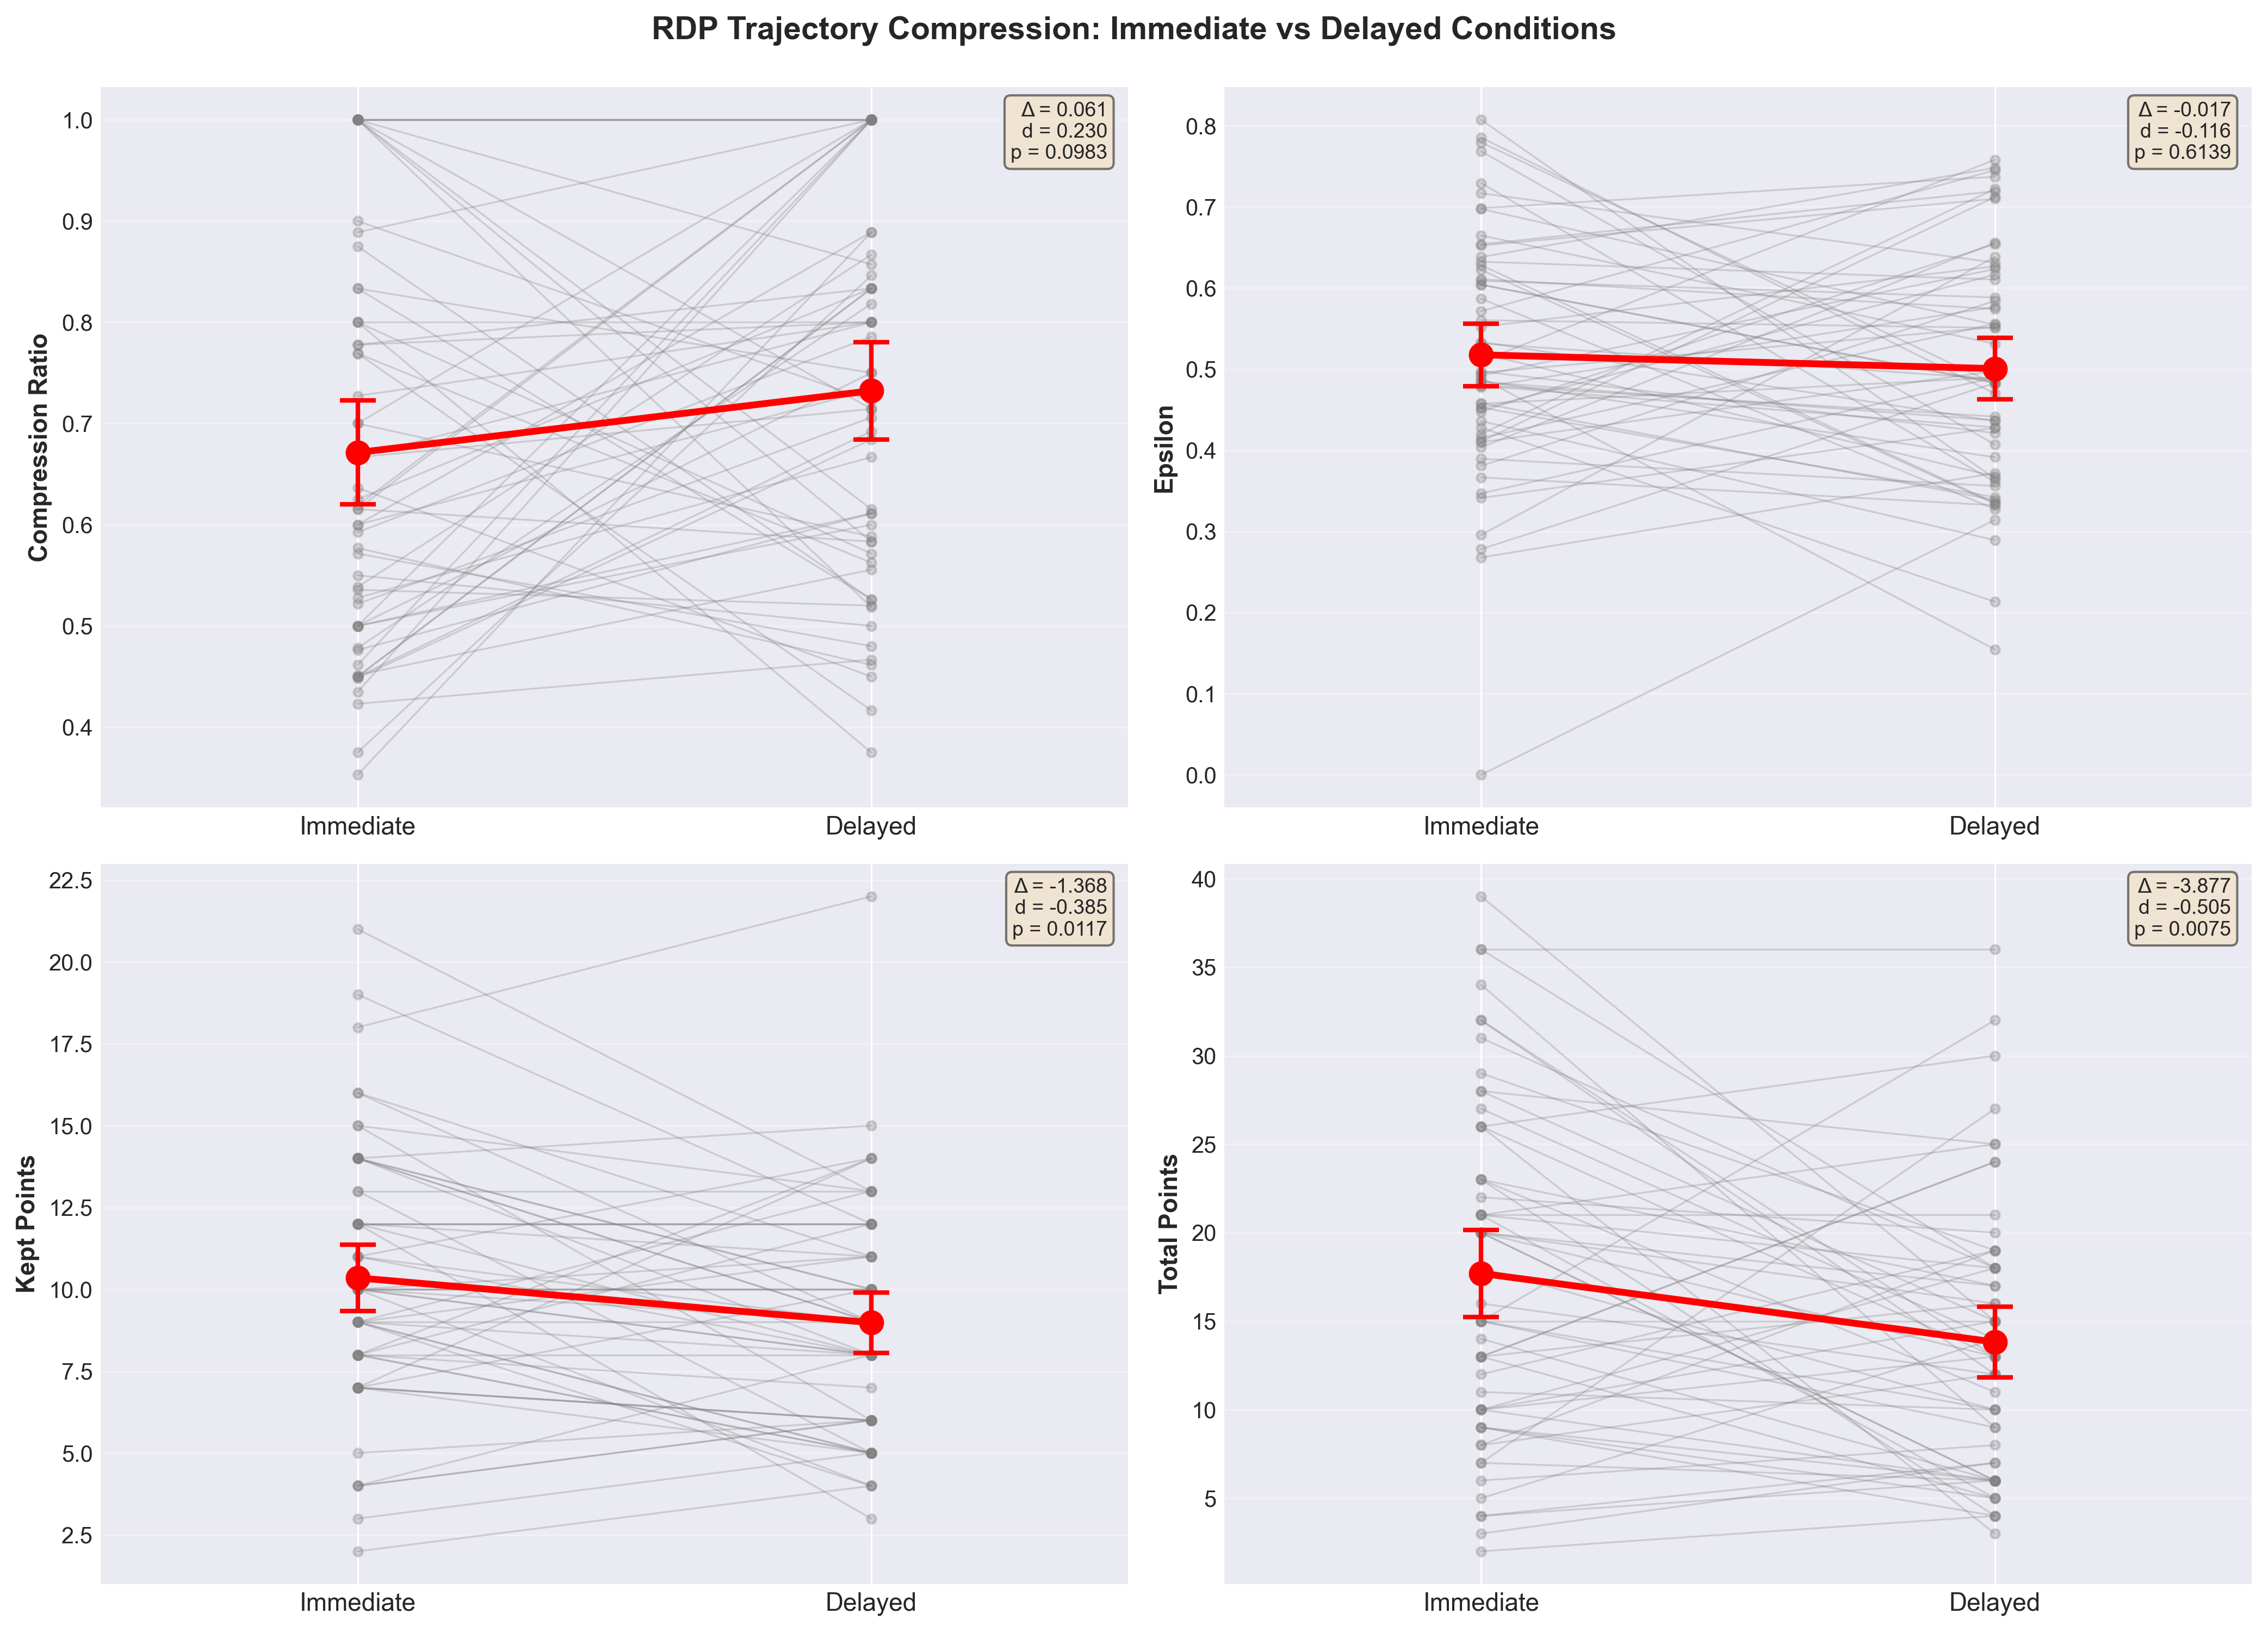

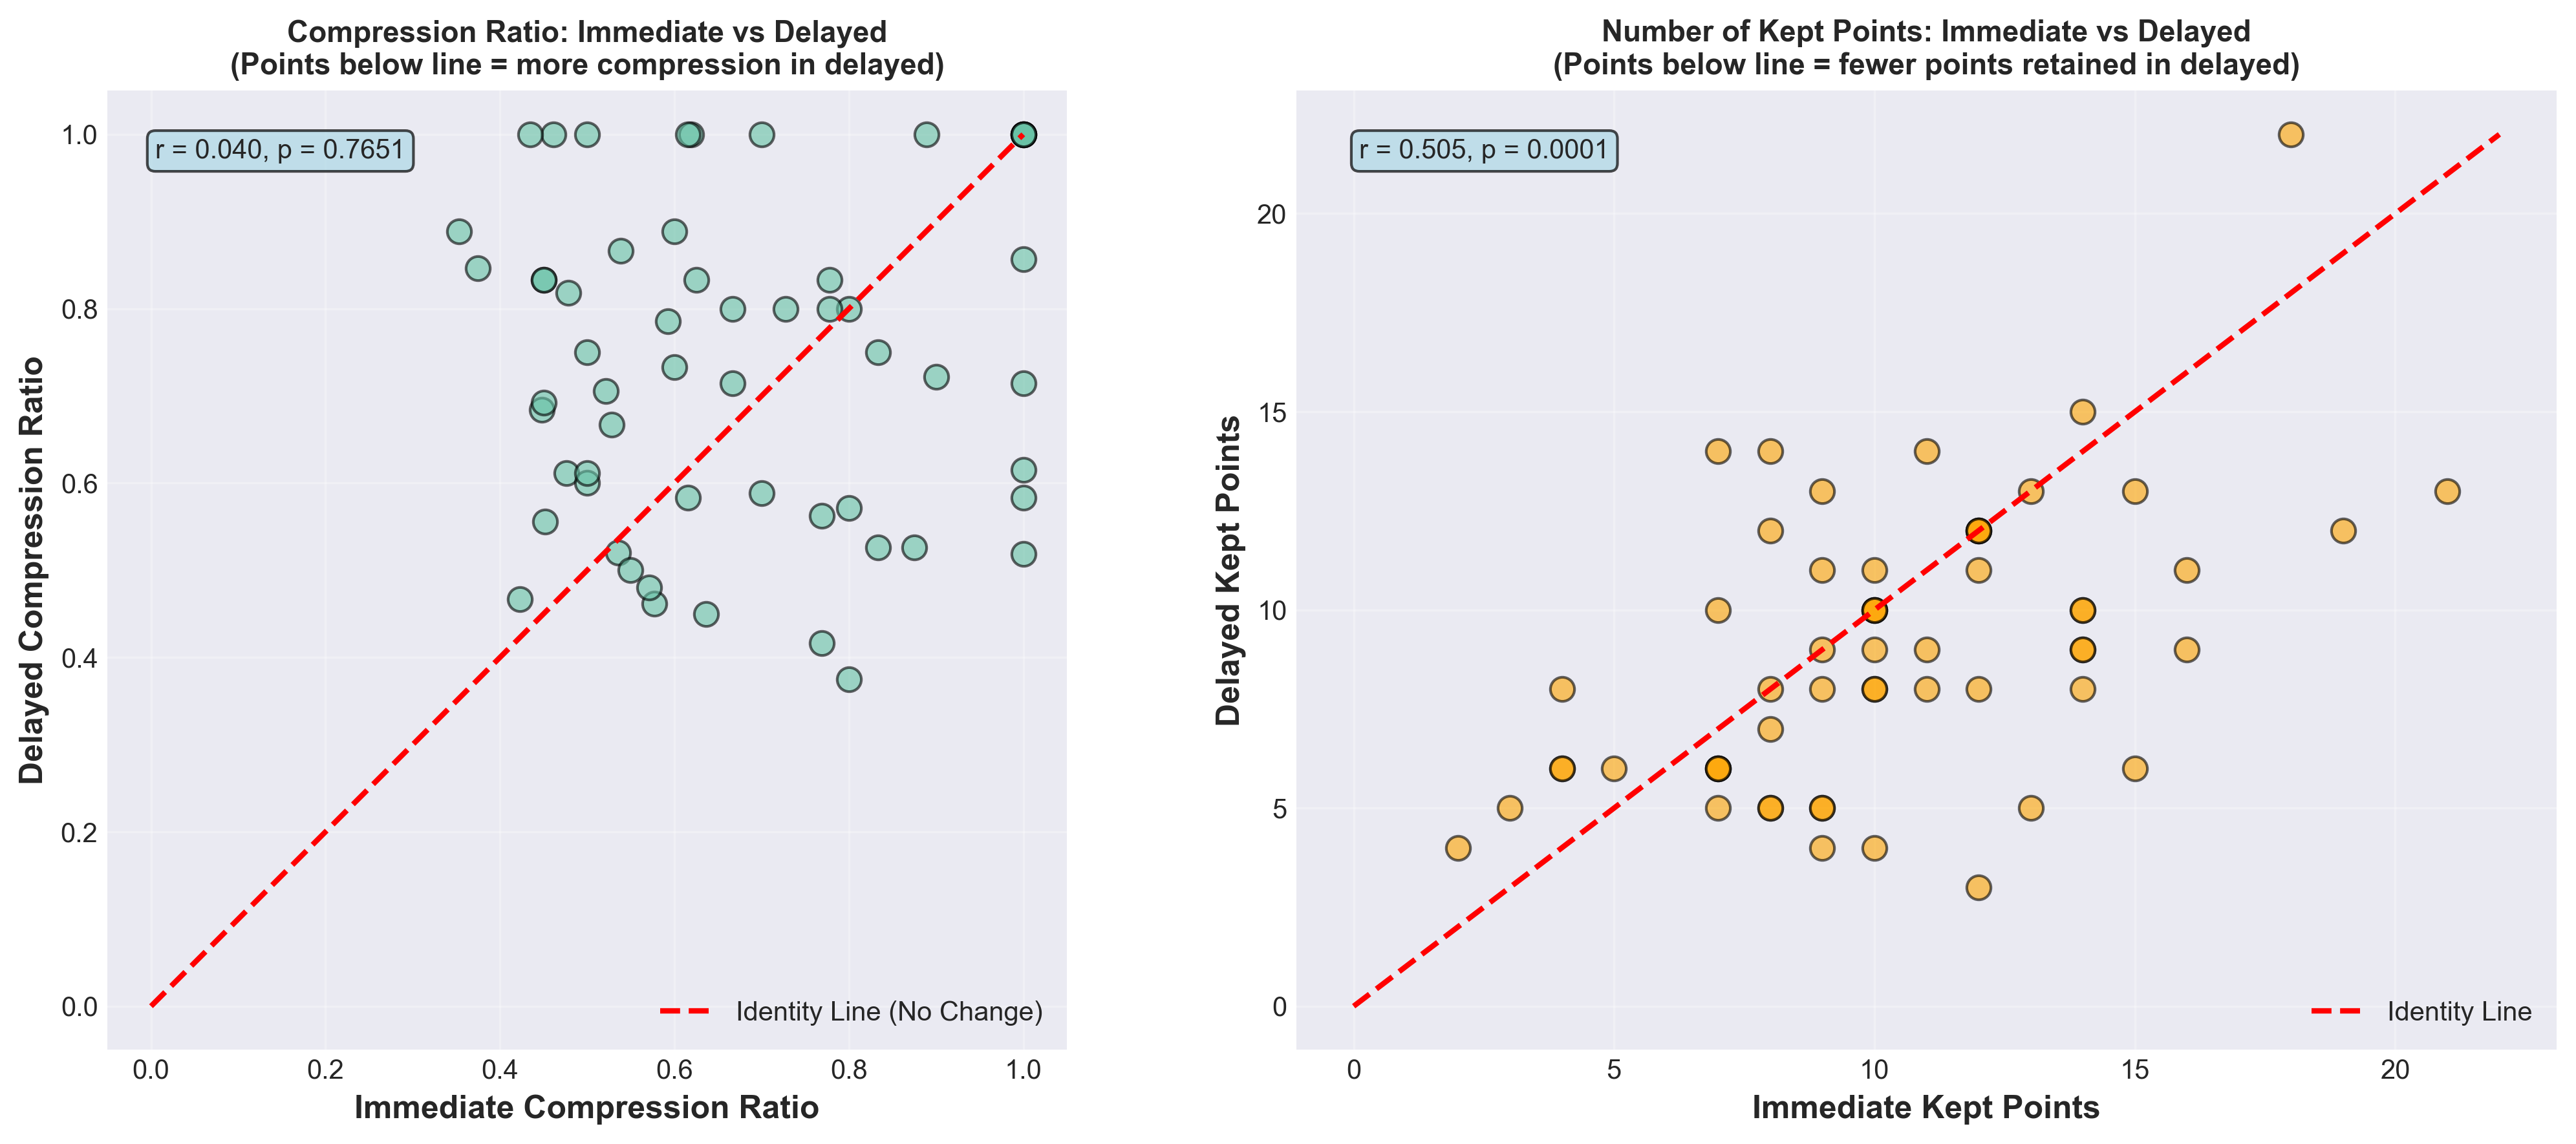

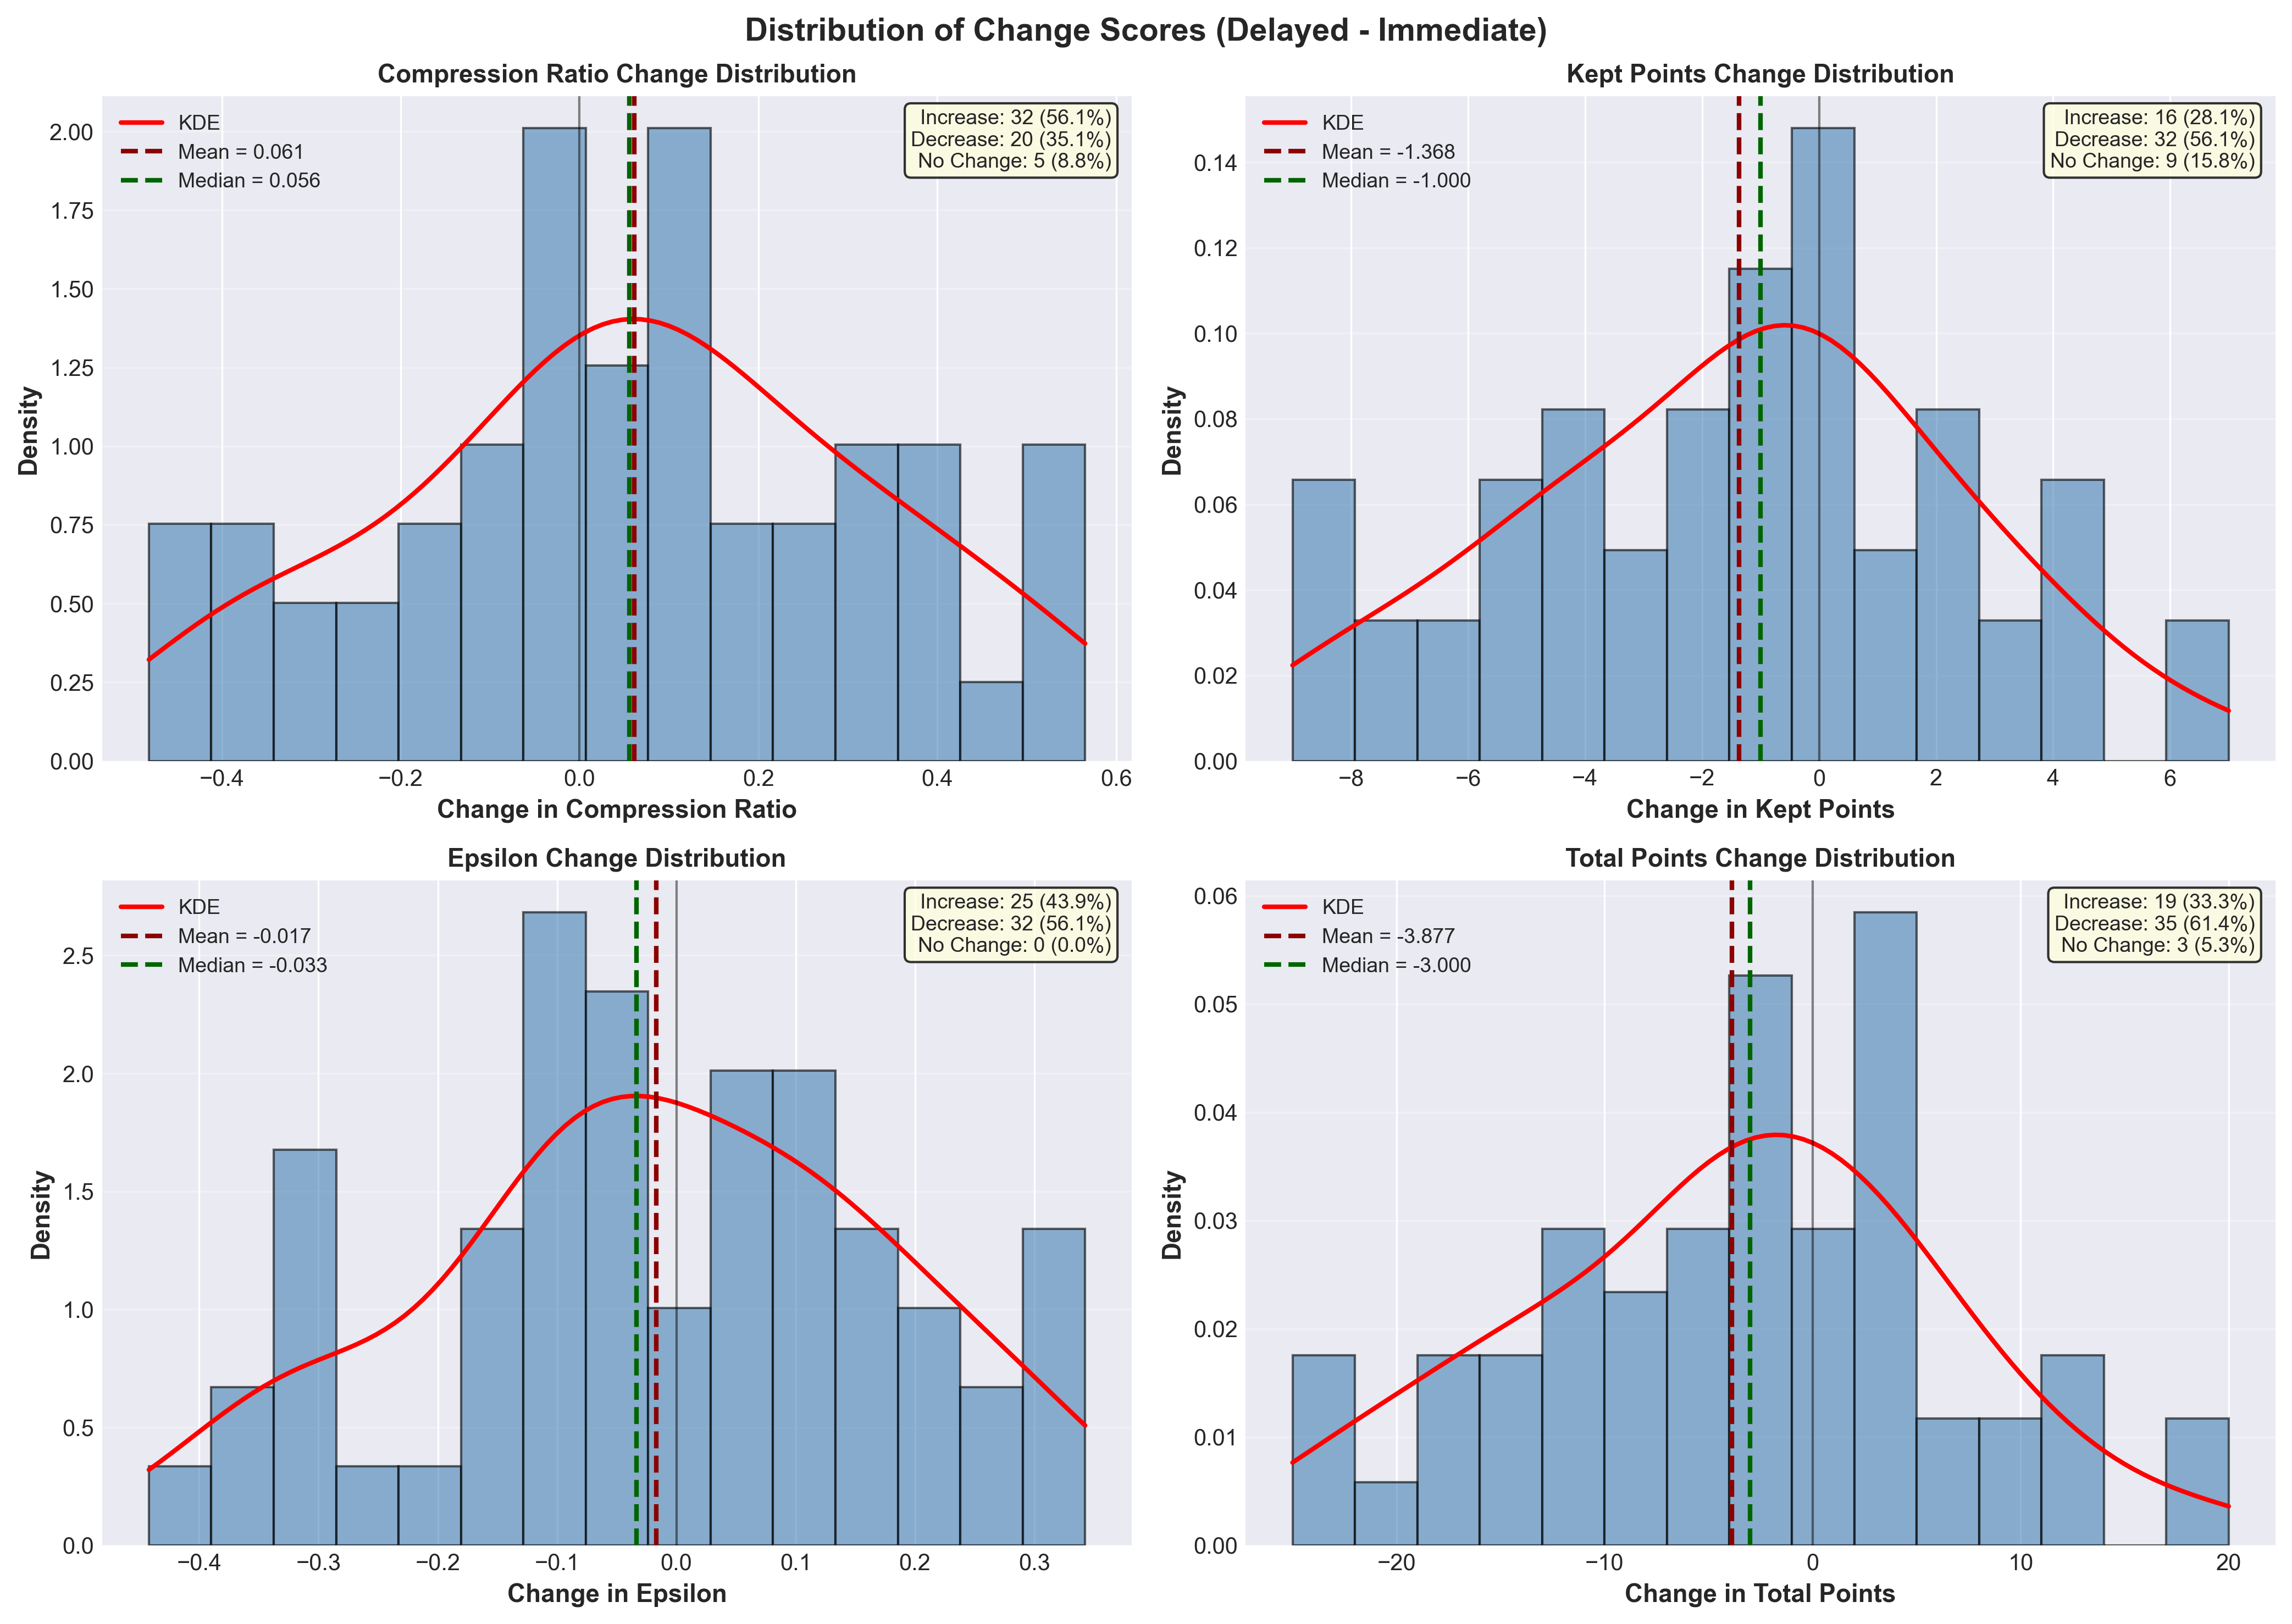

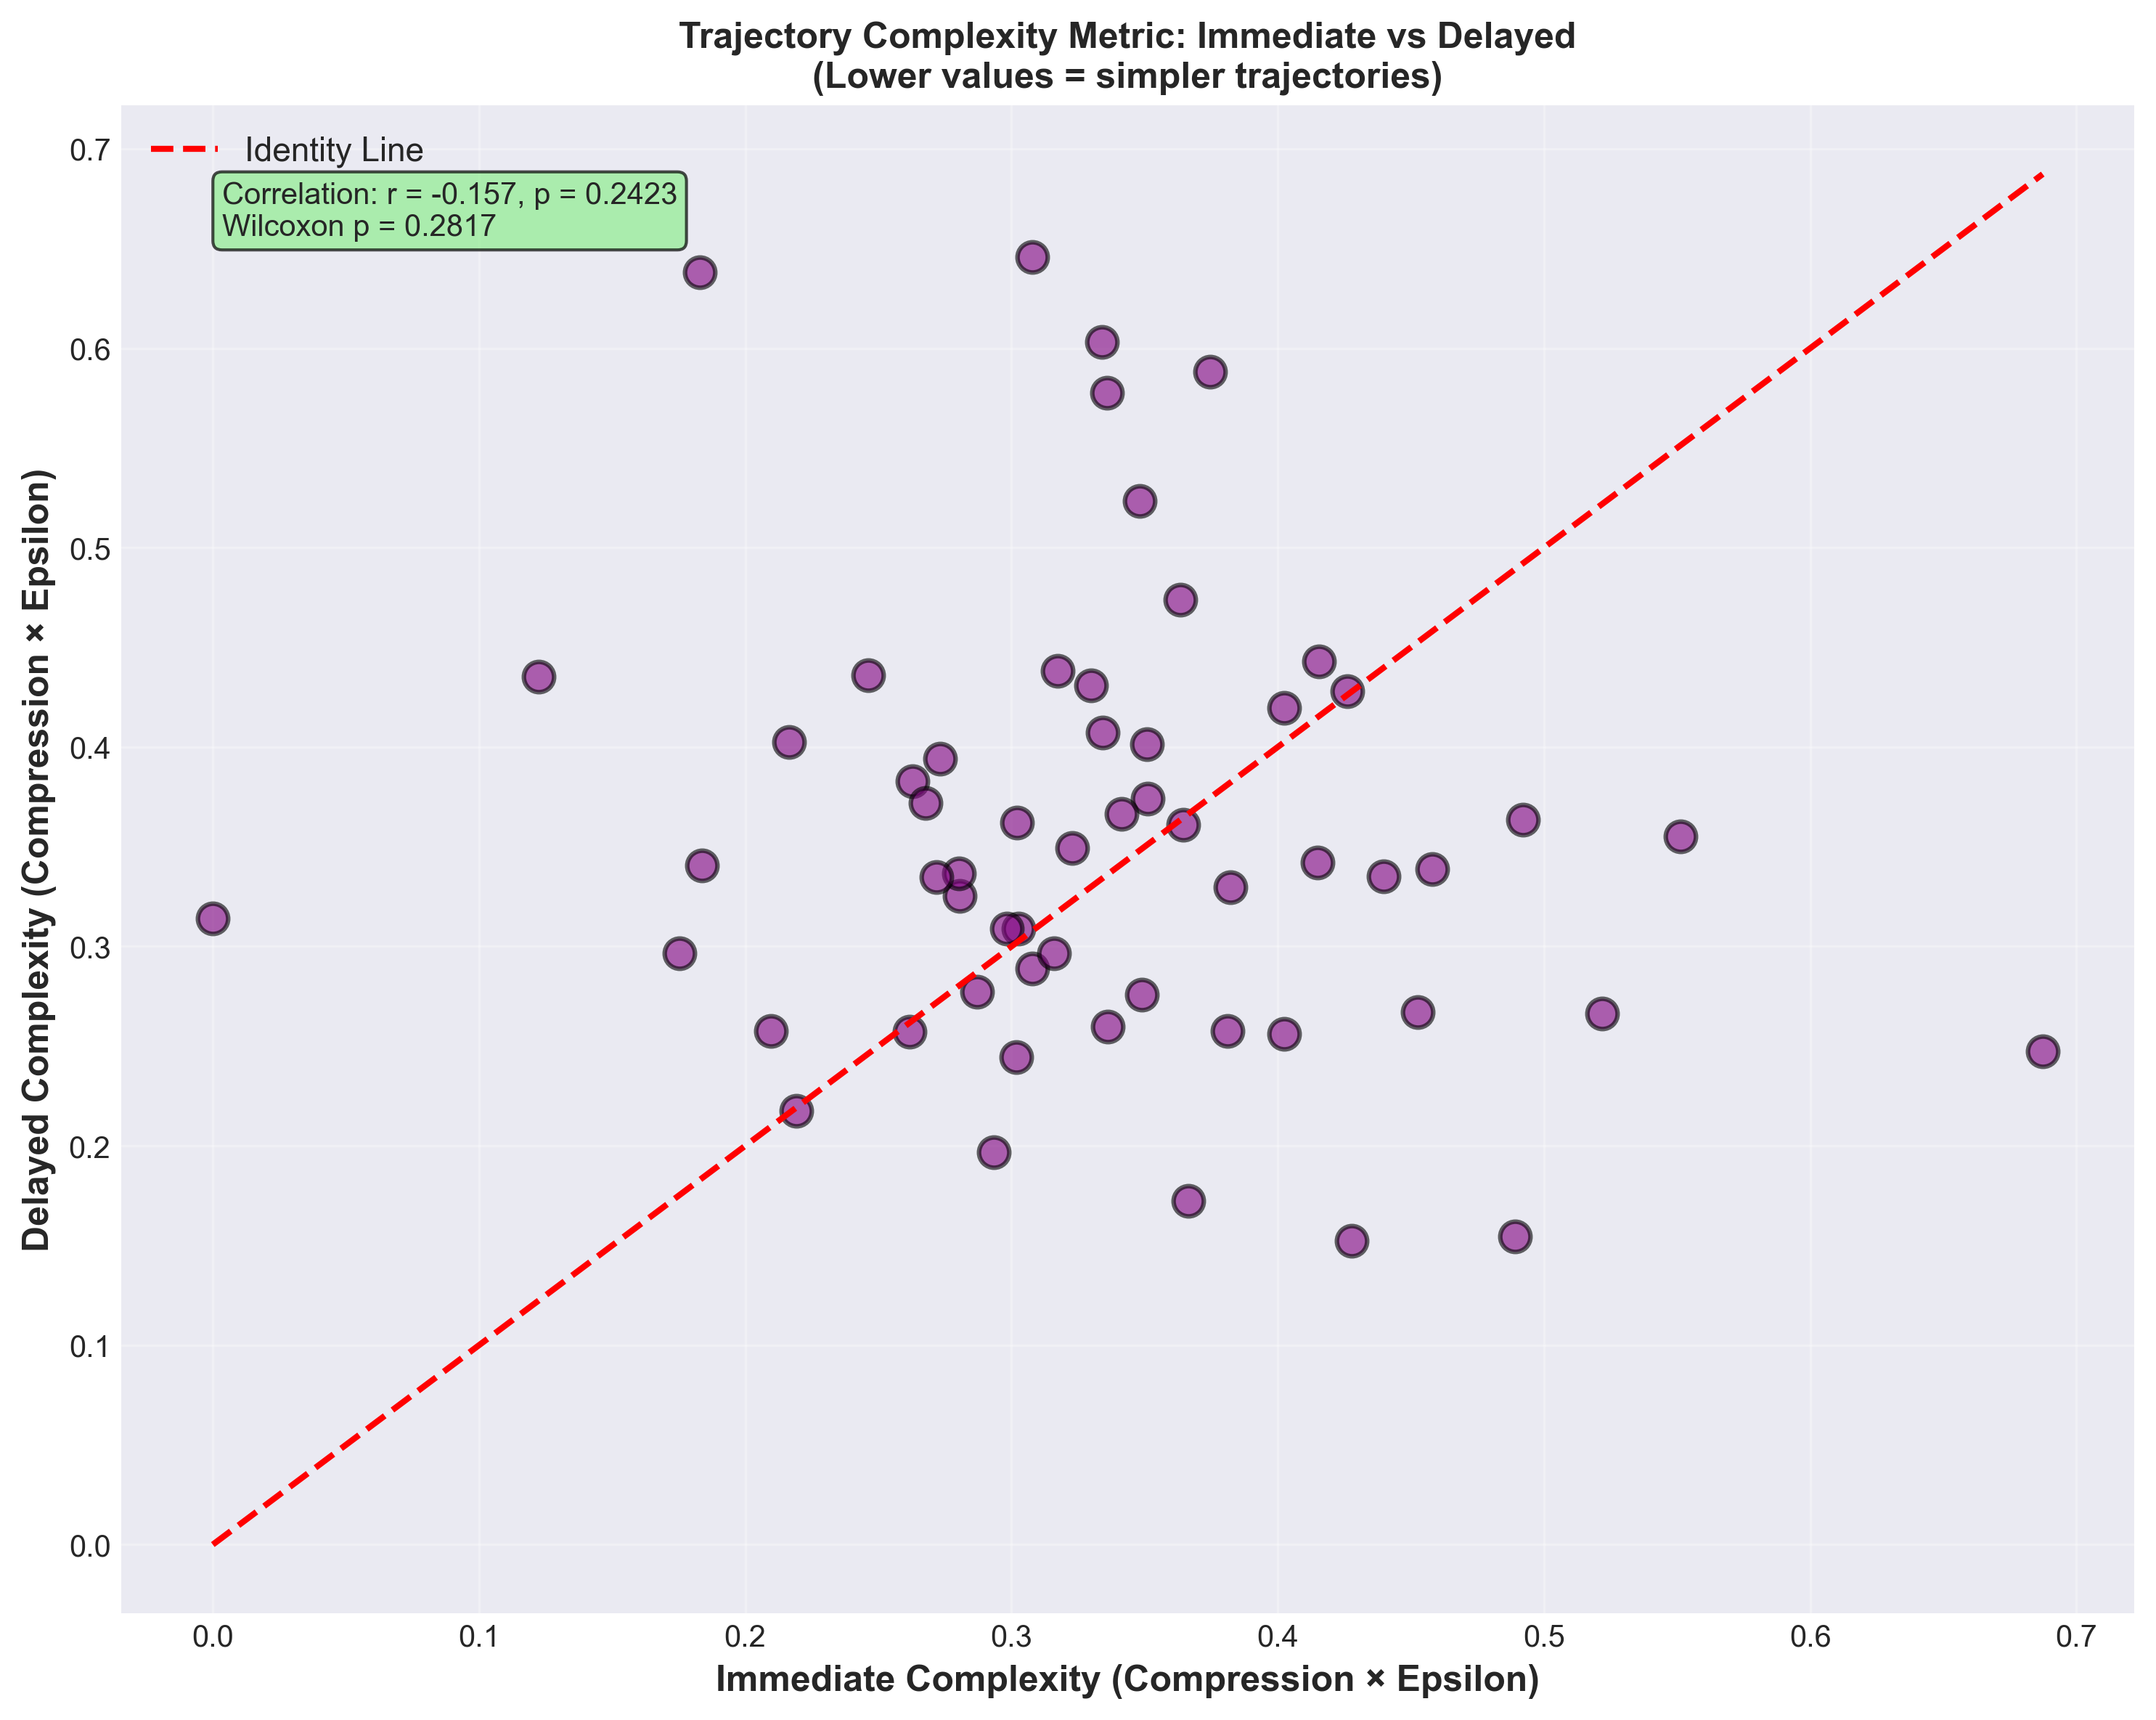

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel, shapiro, normaltest
import warnings
warnings.filterwarnings('ignore')

# styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'

# Load data
df = pd.read_csv(r"C:/Users/Alishba/Downloads/prediction files/Transcriptions/Trajectory Analysis/complete embeddings/rdp_analysis_summary.csv", sep=None, engine="python")

# ============================================================================
# 1. DESCRIPTIVE STATISTICS
# ============================================================================
print("\n" + "="*80)
print("1. DESCRIPTIVE STATISTICS")
print("="*80)

metrics = {
    'Compression Ratio': ('Immediate_Compression_Ratio', 'Delayed_Compression_Ratio'),
    'Epsilon': ('Immediate_Epsilon', 'Delayed_Epsilon'),
    'Kept Points': ('Immediate_Kept_Points', 'Delayed_Kept_Points'),
    'Total Points': ('Immediate_Total_Points', 'Delayed_Total_Points')
}

summary_stats = []
for metric_name, (imm_col, del_col) in metrics.items():
    imm_mean = df[imm_col].mean()
    imm_std = df[imm_col].std()
    del_mean = df[del_col].mean()
    del_std = df[del_col].std()
    
    summary_stats.append({
        'Metric': metric_name,
        'Immediate Mean (SD)': f"{imm_mean:.3f} ({imm_std:.3f})",
        'Delayed Mean (SD)': f"{del_mean:.3f} ({del_std:.3f})",
        'Difference': f"{del_mean - imm_mean:.3f}"
    })

summary_df = pd.DataFrame(summary_stats)
print("\n", summary_df.to_string(index=False))

# ============================================================================
# 2. STATISTICAL TESTS
# ============================================================================
print("\n" + "="*80)
print("2. STATISTICAL ANALYSIS")
print("="*80)

results = []
for metric_name, (imm_col, del_col) in metrics.items():
    imm = df[imm_col].dropna()
    delayed = df[del_col].dropna()
    
    # Test for normality
    _, p_norm_imm = shapiro(imm)
    _, p_norm_del = shapiro(delayed)
    diff = delayed - imm
    _, p_norm_diff = shapiro(diff)
    
    # Paired t-test
    t_stat, p_ttest = ttest_rel(imm, delayed)
    
    # Wilcoxon signed-rank test (non-parametric)
    w_stat, p_wilcoxon = wilcoxon(imm, delayed)
    
    # Effect size (Cohen's d for paired samples)
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    cohens_d = mean_diff / std_diff
    
    # 95% Confidence Interval
    se = std_diff / np.sqrt(len(diff))
    ci_lower = mean_diff - 1.96 * se
    ci_upper = mean_diff + 1.96 * se
    
    results.append({
        'Metric': metric_name,
        'Mean Diff': f"{mean_diff:.4f}",
        "Cohen's d": f"{cohens_d:.3f}",
        '95% CI': f"[{ci_lower:.3f}, {ci_upper:.3f}]",
        't-test p': f"{p_ttest:.4f}",
        'Wilcoxon p': f"{p_wilcoxon:.4f}",
        'Normal?': 'Yes' if p_norm_diff > 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))

# ============================================================================
# 3. VISUALIZATIONS
# ============================================================================

# Figure 1: Paired Comparison Plot (Main Result)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RDP Trajectory Compression: Immediate vs Delayed Conditions', 
             fontsize=14, fontweight='bold', y=0.995)

for idx, (metric_name, (imm_col, del_col)) in enumerate(metrics.items()):
    ax = axes[idx // 2, idx % 2]
    
    # Individual participant lines
    for i in range(len(df)):
        ax.plot([1, 2], [df.iloc[i][imm_col], df.iloc[i][del_col]], 
               'o-', color='gray', alpha=0.3, linewidth=0.8, markersize=4)
    
    # Mean lines
    imm_mean = df[imm_col].mean()
    del_mean = df[del_col].mean()
    ax.plot([1, 2], [imm_mean, del_mean], 'o-', color='red', 
           linewidth=3, markersize=10, label='Mean', zorder=10)
    
    # Error bars (95% CI)
    imm_se = df[imm_col].sem() * 1.96
    del_se = df[del_col].sem() * 1.96
    ax.errorbar([1, 2], [imm_mean, del_mean], yerr=[imm_se, del_se],
               color='red', linewidth=2, capsize=8, capthick=2, zorder=10)
    
    # Styling
    ax.set_xlim(0.5, 2.5)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Immediate', 'Delayed'], fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add statistics annotation
    diff = del_mean - imm_mean
    _, p_val = wilcoxon(df[imm_col], df[del_col])
    cohens_d = diff / df[f'Difference_Compression'].std() if 'Compression' in metric_name else diff / df[del_col].std()
    
    stat_text = f"Δ = {diff:.3f}\nd = {cohens_d:.3f}\np = {p_val:.4f}"
    ax.text(0.98, 0.98, stat_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           fontsize=9)

plt.tight_layout()
plt.savefig('figure1_paired_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: figure1_paired_comparison.png")

# Figure 2: Scatterplot - Individual Differences
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Compression Ratio Scatterplot
ax = axes[0]
imm_comp = df['Immediate_Compression_Ratio']
del_comp = df['Delayed_Compression_Ratio']

ax.scatter(imm_comp, del_comp, s=80, alpha=0.6, edgecolors='black', linewidth=1)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Identity Line (No Change)')

# Add marginal histograms info
ax.set_xlabel('Immediate Compression Ratio', fontsize=12, fontweight='bold')
ax.set_ylabel('Delayed Compression Ratio', fontsize=12, fontweight='bold')
ax.set_title('Compression Ratio: Immediate vs Delayed\n(Points below line = more compression in delayed)',
            fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Add correlation
r, p = stats.pearsonr(imm_comp, del_comp)
ax.text(0.05, 0.95, f'r = {r:.3f}, p = {p:.4f}', transform=ax.transAxes,
       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Kept Points Scatterplot
ax = axes[1]
imm_kept = df['Immediate_Kept_Points']
del_kept = df['Delayed_Kept_Points']

ax.scatter(imm_kept, del_kept, s=80, alpha=0.6, edgecolors='black', linewidth=1, color='orange')
max_val = max(imm_kept.max(), del_kept.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Identity Line')

ax.set_xlabel('Immediate Kept Points', fontsize=12, fontweight='bold')
ax.set_ylabel('Delayed Kept Points', fontsize=12, fontweight='bold')
ax.set_title('Number of Kept Points: Immediate vs Delayed\n(Points below line = fewer points retained in delayed)',
            fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

r, p = stats.pearsonr(imm_kept, del_kept)
ax.text(0.05, 0.95, f'r = {r:.3f}, p = {p:.4f}', transform=ax.transAxes,
       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.savefig('figure2_scatterplot_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figure2_scatterplot_analysis.png")

# Figure 3: Distribution of Change Scores
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Change Scores (Delayed - Immediate)', 
             fontsize=14, fontweight='bold')

change_metrics = {
    'Compression Ratio': 'Difference_Compression',
    'Kept Points': 'Difference_Kept_Points'
}

# Add computed differences for other metrics
df['Diff_Epsilon'] = df['Delayed_Epsilon'] - df['Immediate_Epsilon']
df['Diff_Total_Points'] = df['Delayed_Total_Points'] - df['Immediate_Total_Points']

all_diffs = [
    ('Compression Ratio', df['Difference_Compression']),
    ('Kept Points', df['Difference_Kept_Points']),
    ('Epsilon', df['Diff_Epsilon']),
    ('Total Points', df['Diff_Total_Points'])
]

for idx, (name, diff_data) in enumerate(all_diffs):
    ax = axes[idx // 2, idx % 2]
    
    # Histogram with KDE
    ax.hist(diff_data, bins=15, alpha=0.6, color='steelblue', edgecolor='black', density=True)
    
    # Add KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(diff_data)
    x_range = np.linspace(diff_data.min(), diff_data.max(), 100)
    ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
    
    # Add vertical lines for mean and median
    mean_val = diff_data.mean()
    median_val = diff_data.median()
    ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.3f}')
    ax.axvline(median_val, color='darkgreen', linestyle='--', linewidth=2, label=f'Median = {median_val:.3f}')
    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    ax.set_xlabel(f'Change in {name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax.set_title(f'{name} Change Distribution', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add percentage annotations
    n_increase = (diff_data > 0).sum()
    n_decrease = (diff_data < 0).sum()
    n_same = (diff_data == 0).sum()
    total = len(diff_data)
    
    text = f"Increase: {n_increase} ({100*n_increase/total:.1f}%)\n"
    text += f"Decrease: {n_decrease} ({100*n_decrease/total:.1f}%)\n"
    text += f"No Change: {n_same} ({100*n_same/total:.1f}%)"
    
    ax.text(0.98, 0.98, text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
           fontsize=9)

plt.tight_layout()
plt.savefig('figure3_change_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figure3_change_distributions.png")

# Figure 4: Trajectory Complexity Metric (Compression × Epsilon)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Calculate complexity measure
df['Immediate_Complexity'] = df['Immediate_Compression_Ratio'] * df['Immediate_Epsilon']
df['Delayed_Complexity'] = df['Delayed_Compression_Ratio'] * df['Delayed_Epsilon']

ax.scatter(df['Immediate_Complexity'], df['Delayed_Complexity'], 
          s=100, alpha=0.6, edgecolors='black', linewidth=1.5, c='purple')

max_val = max(df['Immediate_Complexity'].max(), df['Delayed_Complexity'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Identity Line')

ax.set_xlabel('Immediate Complexity (Compression × Epsilon)', fontsize=12, fontweight='bold')
ax.set_ylabel('Delayed Complexity (Compression × Epsilon)', fontsize=12, fontweight='bold')
ax.set_title('Trajectory Complexity Metric: Immediate vs Delayed\n(Lower values = simpler trajectories)',
            fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Statistics
r, p = stats.pearsonr(df['Immediate_Complexity'], df['Delayed_Complexity'])
_, p_wilcox = wilcoxon(df['Immediate_Complexity'], df['Delayed_Complexity'])
stat_text = f'Correlation: r = {r:.3f}, p = {p:.4f}\nWilcoxon p = {p_wilcox:.4f}'
ax.text(0.05, 0.95, stat_text, transform=ax.transAxes,
       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
       fontsize=10)

plt.tight_layout()
plt.savefig('figure4_complexity_metric.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figure4_complexity_metric.png")

# ============================================================================
# 4. SUMMARY TABLE FOR PRESENTATION
# ============================================================================
print("\n" + "="*80)
print("4. SUMMARY TABLE FOR PRESENTATION")
print("="*80)

presentation_table = []
for metric_name, (imm_col, del_col) in metrics.items():
    imm = df[imm_col]
    delayed = df[del_col]
    diff = delayed - imm
    
    # Effect size
    cohens_d = np.mean(diff) / np.std(diff, ddof=1)
    
    # Test
    _, p_wilcox = wilcoxon(imm, delayed)
    
    # Direction
    if np.mean(diff) > 0:
        direction = "↑ Increased"
    elif np.mean(diff) < 0:
        direction = "↓ Decreased"
    else:
        direction = "→ No change"
    
    # Significance
    if p_wilcox < 0.001:
        sig = "***"
    elif p_wilcox < 0.01:
        sig = "**"
    elif p_wilcox < 0.05:
        sig = "*"
    else:
        sig = "ns"
    
    presentation_table.append({
        'Measure': metric_name,
        'Immediate': f"{imm.mean():.3f} ± {imm.std():.3f}",
        'Delayed': f"{delayed.mean():.3f} ± {delayed.std():.3f}",
        'Change': direction,
        "Cohen's d": f"{cohens_d:.3f}",
        'p-value': f"{p_wilcox:.4f} {sig}"
    })

pres_df = pd.DataFrame(presentation_table)
print("\n", pres_df.to_string(index=False))
print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

# Save to CSV
pres_df.to_csv('presentation_summary_table.csv', index=False)
print("\n✓ Saved: presentation_summary_table.csv")